In [38]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:
df=pd.read_excel("D:/sales/sales_Project/data/raw/online_retail_II.xlsx", sheet_name="Year 2010-2011")

In [40]:
print(df.head())

print("================================")
print(df.isnull().sum())
print(df.duplicated().sum())




  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64
5268


In [41]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


In [42]:
df=df.dropna()
df=df.drop_duplicates()
print(df.isnull().sum())
print(df.duplicated().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64
0


In [43]:
print(df['Country'].value_counts())
print(df['Invoice'].nunique())
print(df['Customer ID'].nunique())
print(df['StockCode'].nunique())
print(df['Description'].nunique())
print(df['Invoice'].nunique())

Country
United Kingdom          356728
Germany                   9480
France                    8476
EIRE                      7475
Spain                     2528
Netherlands               2371
Belgium                   2069
Switzerland               1877
Portugal                  1471
Australia                 1258
Norway                    1086
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
USA                        291
Israel                     247
Unspecified                241
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58
Lebanon                     45


In [44]:
df["Invoice"].astype(str).str.startswith("C").sum()


np.int64(8872)

In [45]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Month_Name"] = df["InvoiceDate"].dt.month_name()
df["Day"] = df["InvoiceDate"].dt.day
df["Day_Name"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour
df["Minute"] = df["InvoiceDate"].dt.minute
df["Second"] = df["InvoiceDate"].dt.second
df["Week"] = df["InvoiceDate"].dt.isocalendar().week
df["Quarter"] = df["InvoiceDate"].dt.quarter

In [46]:
print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  Year  Month  \
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  2010     12   
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  2010     12   
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  2010     12   
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  2010     12   
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  2010     12   

  Month_Name  Day   Day_Name  Hour  Minute  Second  Week  Quarter  
0   December    1  Wednesday     8      26       0    48        4 

In [47]:
orders_per_customer = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
)
df["Customer_Orders"] = df["Customer ID"].map(orders_per_customer)


In [48]:
print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  Year  Month  \
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  2010     12   
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  2010     12   
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  2010     12   
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  2010     12   
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  2010     12   

  Month_Name  Day   Day_Name  Hour  Minute  Second  Week  Quarter  \
0   December    1  Wednesday     8      26       0    48        4

In [49]:
print(df.columns)
df["Cancelled"] = df["Invoice"].astype(str).str.startswith("C").astype(int)
cancelled_orders = df[df["Cancelled"] == 1]
cancelled_orders.head()



Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Year', 'Month', 'Month_Name', 'Day',
       'Day_Name', 'Hour', 'Minute', 'Second', 'Week', 'Quarter',
       'Customer_Orders'],
      dtype='object')


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,Month_Name,Day,Day_Name,Hour,Minute,Second,Week,Quarter,Customer_Orders,Cancelled
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,2010,12,December,1,Wednesday,9,41,0,48,4,86,1
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,2010,12,December,1,Wednesday,9,49,0,48,4,118,1
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,2010,12,December,1,Wednesday,10,24,0,48,4,3,1
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,2010,12,December,1,Wednesday,10,24,0,48,4,3,1
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,2010,12,December,1,Wednesday,10,24,0,48,4,3,1


In [50]:
df["Total_Price"] = df["Quantity"] * df["Price"]
df.drop(columns=["Second"], inplace=True)
print(df["Minute"].nunique())
print(df.head())
print(df.columns)


60
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  Year  Month  \
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  2010     12   
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  2010     12   
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  2010     12   
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  2010     12   
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  2010     12   

  Month_Name  Day   Day_Name  Hour  Minute  Week  Quarter  Customer_Orders  \
0   December    1  Wednesday     8      26    48     

<Figure size 800x500 with 0 Axes>

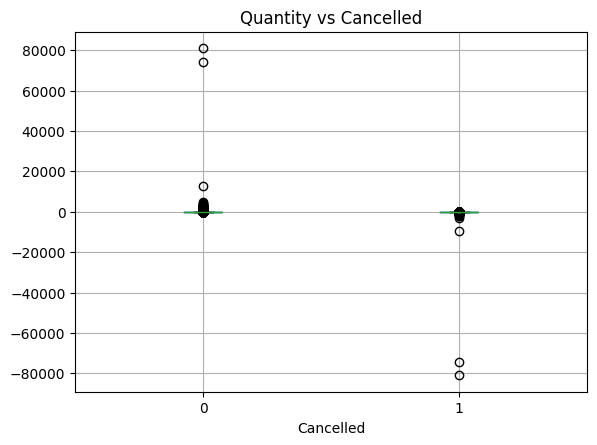

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df.boxplot(column="Quantity", by="Cancelled")
plt.title("Quantity vs Cancelled")
plt.suptitle("")
plt.show()

<Figure size 800x500 with 0 Axes>

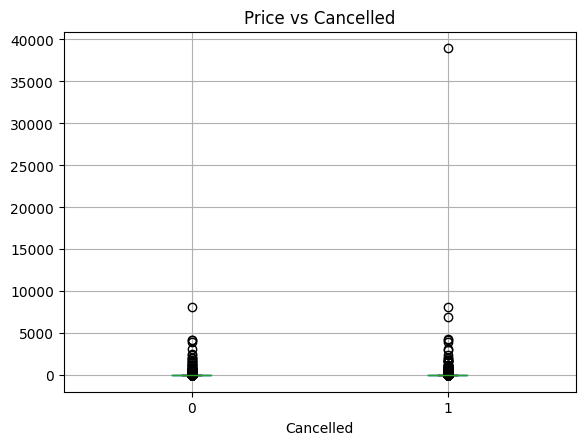

In [52]:
plt.figure(figsize=(8,5))
df.boxplot(column="Price", by="Cancelled")
plt.title("Price vs Cancelled")
plt.suptitle("")
plt.show()

In [53]:

print(df.head())
print(df["Quarter"].nunique())

  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  Year  Month  \
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  2010     12   
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  2010     12   
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  2010     12   
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  2010     12   
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  2010     12   

  Month_Name  Day   Day_Name  Hour  Minute  Week  Quarter  Customer_Orders  \
0   December    1  Wednesday     8      26    48        

In [54]:
import numpy as np
import pandas as pd

# ==========================
# Feature Engineering
# ==========================

# ترتيب البيانات زمنيًا
df = df.sort_values(["Customer ID", "InvoiceDate"])



# 2- عدد المنتجات في الفاتورة
df["Items_Count"] = (
    df.groupby("Invoice")["StockCode"]
      .transform("count")
)

df["Total_Items_Bought"] = (
    df.groupby("Customer ID")["Items_Count"]
      .transform("sum")
)

# 3- عدد المنتجات المختلفة
df["Unique_Products"] = (
    df.groupby("Invoice")["StockCode"]
      .transform("nunique")
)

# 4- متوسط سعر المنتجات
df["Average_Price"] = (
    df.groupby("Invoice")["Price"]
      .transform("mean")
)

# 6- تقسيم ساعات اليوم
def hour_category(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    else:
        return "Night"

df["Hour_Category"] = df["Hour"].apply(hour_category)

# 7- عطلة أم لا؟
df["Weekend"] = (
    df["Day_Name"]
      .isin(["Saturday", "Sunday"])
      .astype(int)
)

# 8- الموسم
def season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

# 9- إجمالي إنفاق العميل


# 10- عدد الفواتير لكل عميل
df["Customer_Frequency"] = (
    df.groupby("Customer ID")["Invoice"]
      .transform("nunique")
)

# 11- عدد الأيام منذ آخر طلب
df["Days_Since_Last_Order"] = (
    df.groupby("Customer ID")["InvoiceDate"]
      .diff()
      .dt.days
      .fillna(0
              )
)

print(df.head())

       Invoice StockCode                        Description  Quantity  \
61619   541431     23166     MEDIUM CERAMIC TOP STORAGE JAR     74215   
61624  C541433     23166     MEDIUM CERAMIC TOP STORAGE JAR    -74215   
14938   537626     85116    BLACK CANDELABRA T-LIGHT HOLDER        12   
14939   537626     22375  AIRLINE BAG VINTAGE JET SET BROWN         4   
14940   537626     71477  COLOUR GLASS. STAR T-LIGHT HOLDER        12   

              InvoiceDate  Price  Customer ID         Country  Year  Month  \
61619 2011-01-18 10:01:00   1.04      12346.0  United Kingdom  2011      1   
61624 2011-01-18 10:17:00   1.04      12346.0  United Kingdom  2011      1   
14938 2010-12-07 14:57:00   2.10      12347.0         Iceland  2010     12   
14939 2010-12-07 14:57:00   4.25      12347.0         Iceland  2010     12   
14940 2010-12-07 14:57:00   3.25      12347.0         Iceland  2010     12   

       ... Total_Price  Items_Count Total_Items_Bought  Unique_Products  \
61619  ...     77

In [55]:


df.drop(columns=["Total_Price"], inplace=True)
df.drop(columns=["Quantity"], inplace=True)

In [56]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'InvoiceDate', 'Price',
       'Customer ID', 'Country', 'Year', 'Month', 'Month_Name', 'Day',
       'Day_Name', 'Hour', 'Minute', 'Week', 'Quarter', 'Customer_Orders',
       'Cancelled', 'Items_Count', 'Total_Items_Bought', 'Unique_Products',
       'Average_Price', 'Hour_Category', 'Weekend', 'Season',
       'Customer_Frequency', 'Days_Since_Last_Order'],
      dtype='object')


In [57]:
df.drop(columns=["Month_Name"], inplace=True)
df.drop(columns=["Day"], inplace=True)
df.drop(columns=["Hour"], inplace=True)

In [58]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'InvoiceDate', 'Price',
       'Customer ID', 'Country', 'Year', 'Month', 'Day_Name', 'Minute', 'Week',
       'Quarter', 'Customer_Orders', 'Cancelled', 'Items_Count',
       'Total_Items_Bought', 'Unique_Products', 'Average_Price',
       'Hour_Category', 'Weekend', 'Season', 'Customer_Frequency',
       'Days_Since_Last_Order'],
      dtype='object')


In [59]:
df["Is_UK"] = (df["Country"] == "United Kingdom").astype(int)


In [60]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'InvoiceDate', 'Price',
       'Customer ID', 'Country', 'Year', 'Month', 'Day_Name', 'Minute', 'Week',
       'Quarter', 'Customer_Orders', 'Cancelled', 'Items_Count',
       'Total_Items_Bought', 'Unique_Products', 'Average_Price',
       'Hour_Category', 'Weekend', 'Season', 'Customer_Frequency',
       'Days_Since_Last_Order', 'Is_UK'],
      dtype='object')


In [61]:
df.drop(columns=["Invoice"], inplace=True)
df.drop(columns=["Customer ID"], inplace=True)
df.drop(columns=["InvoiceDate"], inplace=True)
df.drop(columns=["Description"], inplace=True)

In [62]:
df["Product_Avg_Price"] = (
    df.groupby("StockCode")["Price"]
      .transform("mean")
)

df["Product_Frequency"] = (
    df.groupby("StockCode")["StockCode"]
      .transform("count")
)

In [63]:
df.drop(columns=["Minute"], inplace=True)

In [64]:
print(df.columns)

Index(['StockCode', 'Price', 'Country', 'Year', 'Month', 'Day_Name', 'Week',
       'Quarter', 'Customer_Orders', 'Cancelled', 'Items_Count',
       'Total_Items_Bought', 'Unique_Products', 'Average_Price',
       'Hour_Category', 'Weekend', 'Season', 'Customer_Frequency',
       'Days_Since_Last_Order', 'Is_UK', 'Product_Avg_Price',
       'Product_Frequency'],
      dtype='object')


In [65]:
import numpy as np
import pandas as pd

# =====================================================
# Feature Engineering
# =====================================================

# Price Categories
df["Price_Category"] = pd.qcut(
    df["Price"],
    q=5,
    labels=False,
    duplicates="drop"
)

# Customer Value
df["Customer_Value"] = (
    df["Customer_Orders"] *
    df["Average_Price"]
)

# Customer Lifetime
df["Customer_Lifetime"] = (
    df["Customer_Orders"] *
    df["Average_Price"] *
    df["Total_Items_Bought"]
)

# Items Per Order
df["Items_Per_Order"] = (
    df["Total_Items_Bought"] /
    (df["Customer_Orders"] + 1)
)

# Products Per Order
df["Products_Per_Order"] = (
    df["Unique_Products"] /
    (df["Customer_Orders"] + 1)
)

# Product Diversity
df["Product_Diversity"] = (
    df["Unique_Products"] /
    (df["Total_Items_Bought"] + 1)
)

# Average Items Per Product
df["Avg_Items_Per_Product"] = (
    df["Total_Items_Bought"] /
    (df["Unique_Products"] + 1)
)

# Customer Spend Per Order
df["Spend_Per_Order"] = (
    df["Customer_Value"] /
    (df["Customer_Orders"] + 1)
)

# Average Spend Per Product
df["Spend_Per_Product"] = (
    df["Customer_Value"] /
    (df["Unique_Products"] + 1)
)

# =====================================================
# Log Features
# =====================================================

log_cols = [
    "Price",
    "Customer_Orders",
    "Items_Count",
    "Total_Items_Bought",
    "Unique_Products",
    "Average_Price",
    "Customer_Frequency",
    "Product_Frequency",
    "Days_Since_Last_Order",
    "Customer_Value",
    "Customer_Lifetime"
]

for col in log_cols:
    if col in df.columns:
        df[col + "_Log"] = np.log1p(df[col])

# =====================================================
# Binary Features
# =====================================================

df["High_Frequency_Customer"] = (
    df["Customer_Frequency"] >
    df["Customer_Frequency"].median()
).astype(int)

df["Expensive_Product"] = (
    df["Price"] >
    df["Price"].median()
).astype(int)

df["Loyal_Customer"] = (
    df["Customer_Orders"] >=
    df["Customer_Orders"].quantile(0.75)
).astype(int)

df["New_Customer"] = (
    df["Customer_Orders"] <=
    df["Customer_Orders"].quantile(0.25)
).astype(int)

df["Rare_Product"] = (
    df["Product_Frequency"] <
    df["Product_Frequency"].quantile(0.25)
).astype(int)

df["Popular_Product"] = (
    df["Product_Frequency"] >
    df["Product_Frequency"].quantile(0.75)
).astype(int)

# =====================================================
# Interaction Features
# =====================================================

df["Price_x_CustomerOrders"] = (
    df["Price"] *
    df["Customer_Orders"]
)

df["Price_x_ProductFreq"] = (
    df["Price"] *
    df["Product_Frequency"]
)

df["Orders_x_ProductFreq"] = (
    df["Customer_Orders"] *
    df["Product_Frequency"]
)

df["Orders_x_Items"] = (
    df["Customer_Orders"] *
    df["Items_Count"]
)

df["Items_x_Price"] = (
    df["Items_Count"] *
    df["Price"]
)

df["Items_x_ProductFreq"] = (
    df["Items_Count"] *
    df["Product_Frequency"]
)

df["AveragePrice_x_ProductFreq"] = (
    df["Average_Price"] *
    df["Product_Frequency"]
)

df["AveragePrice_x_Orders"] = (
    df["Average_Price"] *
    df["Customer_Orders"]
)

# =====================================================
# Ratios
# =====================================================

df["Order_to_Product_Ratio"] = (
    df["Customer_Orders"] /
    (df["Unique_Products"] + 1)
)

df["Price_to_ProductFreq"] = (
    df["Price"] /
    (df["Product_Frequency"] + 1)
)

df["Frequency_to_Order"] = (
    df["Customer_Frequency"] /
    (df["Customer_Orders"] + 1)
)

df["Price_to_Items"] = (
    df["Price"] /
    (df["Items_Count"] + 1)
)

print("=" * 60)
print("Feature Engineering Finished")
print("Shape :", df.shape)
print("New Columns :", len(df.columns))
print("=" * 60)

Feature Engineering Finished
Shape : (401605, 60)
New Columns : 60


In [66]:

numeric_columns = df.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()



categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numeric Columns:
['Price', 'Year', 'Month', 'Quarter', 'Customer_Orders', 'Cancelled', 'Items_Count', 'Total_Items_Bought', 'Unique_Products', 'Average_Price', 'Weekend', 'Customer_Frequency', 'Days_Since_Last_Order', 'Is_UK', 'Product_Avg_Price', 'Product_Frequency', 'Price_Category', 'Customer_Value', 'Customer_Lifetime', 'Items_Per_Order', 'Products_Per_Order', 'Product_Diversity', 'Avg_Items_Per_Product', 'Spend_Per_Order', 'Spend_Per_Product', 'Price_Log', 'Customer_Orders_Log', 'Items_Count_Log', 'Total_Items_Bought_Log', 'Unique_Products_Log', 'Average_Price_Log', 'Customer_Frequency_Log', 'Product_Frequency_Log', 'Days_Since_Last_Order_Log', 'Customer_Value_Log', 'Customer_Lifetime_Log', 'High_Frequency_Customer', 'Expensive_Product', 'Loyal_Customer', 'New_Customer', 'Rare_Product', 'Popular_Product', 'Price_x_CustomerOrders', 'Price_x_ProductFreq', 'Orders_x_ProductFreq', 'Orders_x_Items', 'Items_x_Price', 'Items_x_ProductFreq', 'AveragePrice_x_ProductFreq', 'AveragePrice_x_O

In [67]:
"""majority = train_df[train_df["Cancelled"] == 0].reset_index(drop=True)
minority = train_df[train_df["Cancelled"] == 1].reset_index(drop=True)

X_majority = majority.drop(columns=["Cancelled"])

for col in categorical_columns:
    X_majority[col] = X_majority[col].astype(str)

preprocessor_similarity = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

X_similarity = preprocessor_similarity.fit_transform(X_majority)

nn = NearestNeighbors(
    n_neighbors=2,
    metric="cosine",
    algorithm="brute",
    n_jobs=-1
)

nn.fit(X_similarity)

distances, indices = nn.kneighbors(X_similarity)

rows_to_remove = set()

SIMILARITY_THRESHOLD = 0.98

for i in range(len(indices)):
    neighbor = indices[i][1]
    similarity = 1 - distances[i][1]

    if similarity >= SIMILARITY_THRESHOLD:
        rows_to_remove.add(neighbor)

print("=" * 60)
print("Majority Duplicates Removed :", len(rows_to_remove))
print("=" * 60)

majority = majority.drop(index=list(rows_to_remove)).reset_index(drop=True)

train_df = pd.concat([majority, minority], ignore_index=True)

train_df = train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X_train = train_df.drop(columns=["Cancelled"])
y_train = train_df["Cancelled"]

print(X_train.shape)
print(y_train.value_counts())
"""

'majority = train_df[train_df["Cancelled"] == 0].reset_index(drop=True)\nminority = train_df[train_df["Cancelled"] == 1].reset_index(drop=True)\n\nX_majority = majority.drop(columns=["Cancelled"])\n\nfor col in categorical_columns:\n    X_majority[col] = X_majority[col].astype(str)\n\npreprocessor_similarity = ColumnTransformer(\n    transformers=[\n        ("num", StandardScaler(), numeric_columns),\n        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)\n    ]\n)\n\nX_similarity = preprocessor_similarity.fit_transform(X_majority)\n\nnn = NearestNeighbors(\n    n_neighbors=2,\n    metric="cosine",\n    algorithm="brute",\n    n_jobs=-1\n)\n\nnn.fit(X_similarity)\n\ndistances, indices = nn.kneighbors(X_similarity)\n\nrows_to_remove = set()\n\nSIMILARITY_THRESHOLD = 0.98\n\nfor i in range(len(indices)):\n    neighbor = indices[i][1]\n    similarity = 1 - distances[i][1]\n\n    if similarity >= SIMILARITY_THRESHOLD:\n        rows_to_remove.add(neighbor)\n\nprint("="

In [68]:
"""from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# =====================================================
# SMOTE
# =====================================================

# =====================================================
# Prepare Final Train Data
# =====================================================

X_train = train_df.drop(columns=["Cancelled"])
y_train = train_df["Cancelled"]

# مهم جداً
for col in categorical_columns:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# =====================================================
# Final Preprocessing
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# =====================================================
# SMOTE
# =====================================================

sm = SMOTE(
    random_state=42
)

X_train, y_train = sm.fit_resample(
    X_train,
    y_train
)

# =====================================================
# Class Weight
# =====================================================

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos = neg / pos

print("=" * 60)
print("Training Shape :", X_train.shape)
print("Positive :", pos)
print("Negative :", neg)
print("=" * 60)

# =====================================================
# XGBoost
# =====================================================

model = XGBClassifier(

    objective="binary:logistic",
    eval_metric="logloss",

    n_estimators=300,
    learning_rate=0.03,

    max_depth=7,
    min_child_weight=2,

    subsample=0.85,
    colsample_bytree=0.85,

    gamma=0.15,

    reg_alpha=0.2,
    reg_lambda=2,

    scale_pos_weight=scale_pos,

    random_state=42,
    n_jobs=-1
)

# =====================================================
# Train
# =====================================================

model.fit(
    X_train,
    y_train,
    verbose=False
)

# =====================================================
# Predict Probabilities
# =====================================================

proba = model.predict_proba(X_test)[:, 1]

# =====================================================
# Best Threshold
# =====================================================

best_f1 = 0
best_threshold = 0.50

for t in np.arange(0.01, 0.99, 0.01):

    pred = (proba >= t).astype(int)

    score = f1_score(y_test, pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

# =====================================================
# Final Prediction
# =====================================================

pred = (proba >= best_threshold).astype(int)

acc = accuracy_score(y_test, pred)
pre = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
auc = roc_auc_score(y_test, proba)

cm = confusion_matrix(y_test, pred)

# =====================================================
# Results
# =====================================================

print("\n")
print("=" * 70)
print("XGBOOST RESULTS")
print("=" * 70)

print(f"Best Threshold : {best_threshold:.2f}")
print(f"Accuracy       : {acc:.4f}")
print(f"Precision      : {pre:.4f}")
print(f"Recall         : {rec:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"ROC AUC        : {auc:.4f}")

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(y_test, pred))

print(f"TP : {cm[1,1]}")
print(f"TN : {cm[0,0]}")
print(f"FP : {cm[0,1]}")
print(f"FN : {cm[1,0]}")

# =====================================================
# Feature Importance
# =====================================================

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance = importance[
    importance["Importance"] > 0
]

print("\n")
print("=" * 70)
print("TOP 50 IMPORTANT FEATURES")
print("=" * 70)

print(importance.head(50))

# =====================================================
# Save Importance
# =====================================================

importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("\nFeature importance saved to feature_importance.csv")"""

'from imblearn.over_sampling import SMOTE\n\nfrom xgboost import XGBClassifier\n\nfrom sklearn.metrics import (\n    accuracy_score,\n    precision_score,\n    recall_score,\n    f1_score,\n    confusion_matrix,\n    classification_report,\n    roc_auc_score\n)\n\n# =====================================================\n# SMOTE\n# =====================================================\n\n# =====================================================\n# Prepare Final Train Data\n# =====================================================\n\nX_train = train_df.drop(columns=["Cancelled"])\ny_train = train_df["Cancelled"]\n\n# مهم جداً\nfor col in categorical_columns:\n    X_train[col] = X_train[col].astype(str)\n    X_test[col] = X_test[col].astype(str)\n\n# =====================================================\n# Final Preprocessing\n# =====================================================\n\npreprocessor = ColumnTransformer(\n    transformers=[\n        ("num", "passthrough", numeric_columns),\n    

print(df['Country'].value_counts())
print(df['Invoice'].nunique())
print(df['Customer ID'].nunique())
print(df['StockCode'].nunique())
print(df['Description'].nunique())